In [30]:
!pip install -q xgboost

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, average_precision_score, precision_recall_curve,
    confusion_matrix, classification_report, brier_score_loss
)
from sklearn.inspection import permutation_importance

np.random.seed(42)

print("Libraries loaded.")


Libraries loaded.


In [31]:
url = "https://raw.githubusercontent.com/doguilmak/Heart-Diseaseor-Attack-Classification/main/heart_disease_health_indicators_BRFSS2015.csv"
df = pd.read_csv(url)

print("Shape:", df.shape)
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
df.head()


Shape: (253680, 22)
Memory usage: 44.6 MB


,HeartDiseaseorAttack,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,Diabetes,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [32]:
print(df.info())
print("\nMissing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   HeartDiseaseorAttack  253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   Diabetes              253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  

In [33]:
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after removing duplicates:", df.shape)


Shape after removing duplicates: (229781, 22)


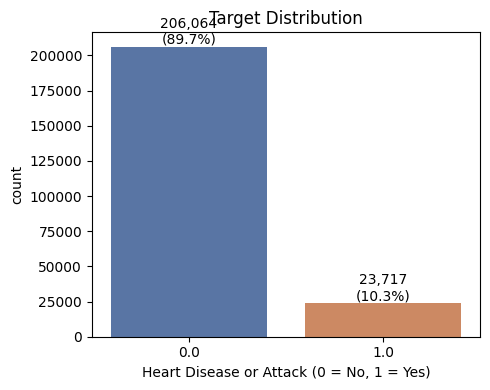

Class imbalance ratio: 8.7 : 1 (no-disease : disease)


In [34]:
target_counts = df['HeartDiseaseorAttack'].value_counts()
target_pct = df['HeartDiseaseorAttack'].value_counts(normalize=True) * 100

plt.figure(figsize=(5, 4))
sns.countplot(x='HeartDiseaseorAttack', hue='HeartDiseaseorAttack', data=df,
              palette=['#4c72b0', '#dd8452'], legend=False)
plt.title('Target Distribution')
plt.xlabel('Heart Disease or Attack (0 = No, 1 = Yes)')
for i, (count, pct) in enumerate(zip(target_counts, target_pct)):
    plt.text(i, count, f'{count:,}\n({pct:.1f}%)', ha='center', va='bottom')
plt.tight_layout()
plt.show()

print(f"Class imbalance ratio: {target_counts[0] / target_counts[1]:.1f} : 1 (no-disease : disease)")


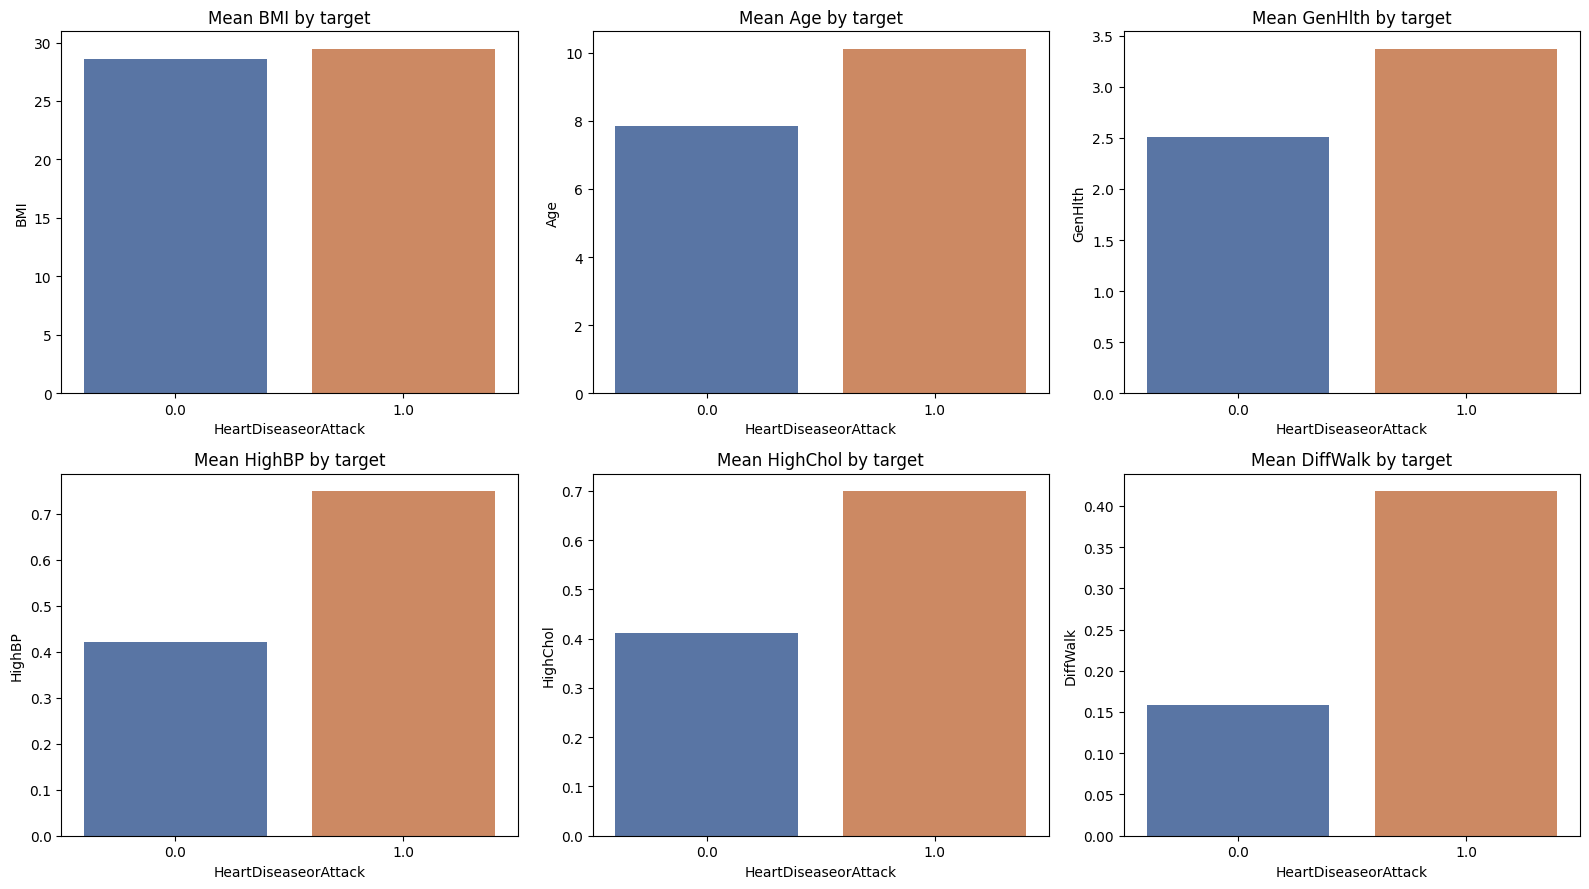

In [35]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
features_to_plot = ['BMI', 'Age', 'GenHlth', 'HighBP', 'HighChol', 'DiffWalk']

for ax, feat in zip(axes.flatten(), features_to_plot):
    sns.barplot(x='HeartDiseaseorAttack', y=feat, hue='HeartDiseaseorAttack', data=df, ax=ax,
                palette=['#4c72b0', '#dd8452'], legend=False, errorbar=None)
    ax.set_title(f'Mean {feat} by target')

plt.tight_layout()
plt.show()


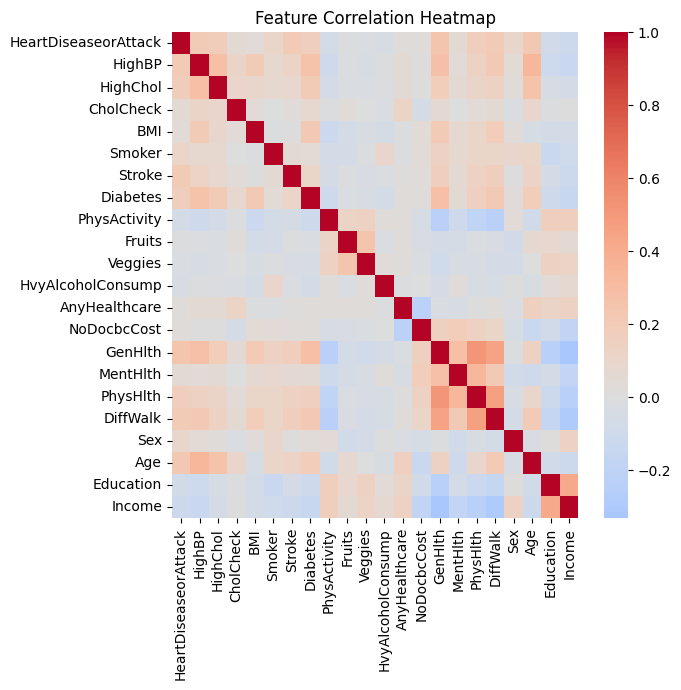

Top 10 features most correlated with the target:
GenHlth     0.246411
Age         0.223626
DiffWalk    0.202779
HighBP      0.201271
Stroke      0.198863
HighChol    0.176279
Diabetes    0.170816
PhysHlth    0.170473
Income      0.122908
Smoker      0.105154
Name: HeartDiseaseorAttack, dtype: float64


In [54]:
plt.figure(figsize=(7, 7))
sns.heatmap(df.corr(), cmap='coolwarm', center=0, annot=False)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

print("Top 10 features most correlated with the target:")
print(df.corr()['HeartDiseaseorAttack'].abs().sort_values(ascending=False)[1:11])


In [37]:
X = df.drop('HeartDiseaseorAttack', axis=1)
y = df['HeartDiseaseorAttack']

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.05, stratify=y, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.05, stratify=y_temp, random_state=42
)

print(f"Train: {X_train.shape[0]:,} samples")
print(f"Val:   {X_val.shape[0]:,} samples")
print(f"Test:  {X_test.shape[0]:,} samples (held out completely until final evaluation)")
print(f"\nPositive class rate — Train: {y_train.mean():.3f}, Val: {y_val.mean():.3f}, Test: {y_test.mean():.3f}")


Train: 207,376 samples
Val:   10,915 samples
Test:  11,490 samples (held out completely until final evaluation)

Positive class rate — Train: 0.103, Val: 0.103, Test: 0.103


In [38]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)


In [39]:
neg, pos = np.bincount(y_train.astype(int))
scale_pos_weight = neg / pos
print(f"Class weight ratio (for XGBoost's scale_pos_weight): {scale_pos_weight:.2f}")


Class weight ratio (for XGBoost's scale_pos_weight): 8.69


In [40]:
X_train_sub, _, y_train_sub, _ = train_test_split(
    X_train_scaled, y_train, train_size=15000, stratify=y_train, random_state=42
)
print(f"Subsample for model screening: {X_train_sub.shape[0]:,} rows "
      f"(positive rate: {y_train_sub.mean():.3f}, matches full training set)")


Subsample for model screening: 15,000 rows (positive rate: 0.103, matches full training set)


In [41]:
candidate_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1),
    "SVM (RBF kernel)": SVC(probability=True, class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(eval_metric='logloss', scale_pos_weight=scale_pos_weight, random_state=42),
}

screening_results = []

for name, clf in candidate_models.items():
    start = time.time()
    clf.fit(X_train_sub, y_train_sub)
    elapsed = time.time() - start

    val_pred = clf.predict(X_val_scaled)
    val_proba = clf.predict_proba(X_val_scaled)[:, 1]

    screening_results.append({
        "Model": name,
        "Val Accuracy": accuracy_score(y_val, val_pred),
        "Val Precision": precision_score(y_val, val_pred),
        "Val Recall": recall_score(y_val, val_pred),
        "Val F1": f1_score(y_val, val_pred),
        "Val ROC-AUC": roc_auc_score(y_val, val_proba),
        "Val PR-AUC": average_precision_score(y_val, val_proba),
        "Train time (s)": round(elapsed, 1),
    })
    print(f"{name}: done in {elapsed:.1f}s")

screening_df = pd.DataFrame(screening_results).set_index("Model").sort_values("Val PR-AUC", ascending=False)
screening_df.round(3)


Logistic Regression: done in 0.1s
Random Forest: done in 6.4s
SVM (RBF kernel): done in 81.7s
XGBoost: done in 0.3s


,Val Accuracy,Val Precision,Val Recall,Val F1,Val ROC-AUC,Val PR-AUC,Train time (s)
Model,,,,,,,
Logistic Regression,0.744,0.254,0.760,0.380,0.831,0.372,0.1
Random Forest,0.897,0.507,0.064,0.113,0.806,0.318,6.4
SVM (RBF kernel),0.763,0.256,0.680,0.372,0.803,0.289,81.7
XGBoost,0.814,0.279,0.505,0.359,0.772,0.289,0.3


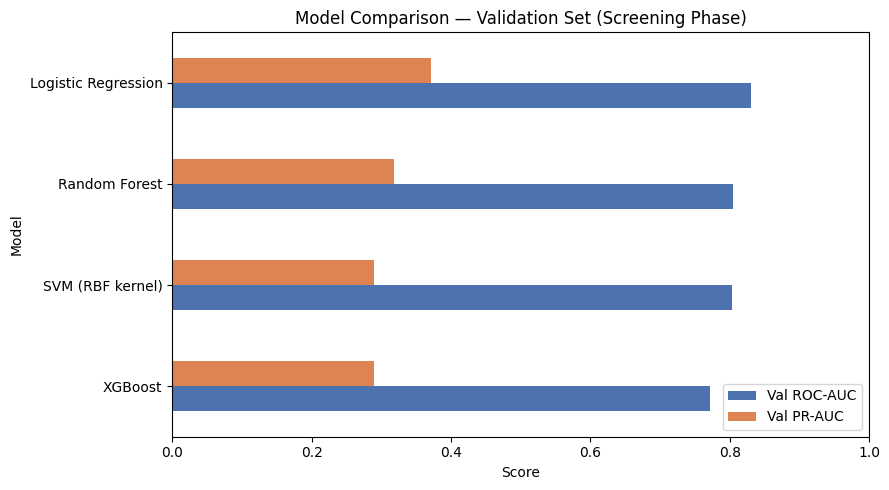

Selected model type (highest validation PR-AUC): Logistic Regression


In [42]:
plt.figure(figsize=(9, 5))
screening_df[['Val ROC-AUC', 'Val PR-AUC']].sort_values('Val PR-AUC').plot(
    kind='barh', ax=plt.gca(), color=['#4c72b0', '#dd8452']
)
plt.xlabel('Score')
plt.title('Model Comparison — Validation Set (Screening Phase)')
plt.xlim(0, 1.0)
plt.tight_layout()
plt.show()

best_model_name = screening_df['Val PR-AUC'].idxmax()
print(f"Selected model type (highest validation PR-AUC): {best_model_name}")


In [43]:
param_grids = {
    "Logistic Regression": {
        'C': [0.01, 0.1, 1, 10, 100],
        'penalty': ['l2'],
        'solver': ['lbfgs'],
    },
    "Random Forest": {
        'n_estimators': [100, 200, 300],
        'max_depth': [5, 10, 15, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
    },
    "SVM (RBF kernel)": {
        'C': [0.1, 1, 10],
        'gamma': ['scale', 'auto', 0.01, 0.1],
    },
    "XGBoost": {
        'n_estimators': [100, 200, 300],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'subsample': [0.7, 0.85, 1.0],
    },
}

base_estimator = type(candidate_models[best_model_name])(**{
    k: v for k, v in candidate_models[best_model_name].get_params().items()
    if k in ('class_weight', 'scale_pos_weight', 'probability', 'eval_metric', 'random_state')
})

search = RandomizedSearchCV(
    base_estimator,
    param_distributions=param_grids[best_model_name],
    n_iter=10,
    scoring='average_precision',
    cv=3,
    random_state=42,
    n_jobs=-1,
)

start = time.time()
search.fit(X_train_sub, y_train_sub)
print(f"Search done in {time.time() - start:.1f}s")
print(f"Best CV PR-AUC: {search.best_score_:.4f}")
print(f"Best params: {search.best_params_}")

best_params = search.best_params_


/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 5 is smaller than n_iter=10. Running 5 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Search done in 4.1s
Best CV PR-AUC: 0.3684
Best params: {'solver': 'lbfgs', 'penalty': 'l2', 'C': 0.01}


In [44]:
if best_model_name == "SVM (RBF kernel)":
    print("SVM was selected, but refitting an RBF-kernel SVM on the full "
          f"{X_train_scaled.shape[0]:,}-row training set is not computationally "
          "practical in this environment. Proceeding with the tuned, subsample-trained "
          "SVM as the final base model, and noting this as an explicit limitation.")
    final_model = search.best_estimator_
else:
    print(f"Refitting tuned {best_model_name} on the full training set...")
    start = time.time()
    final_model = type(candidate_models[best_model_name])(**{
        **{k: v for k, v in candidate_models[best_model_name].get_params().items()
           if k in ('class_weight', 'scale_pos_weight', 'probability', 'eval_metric', 'random_state')},
        **best_params
    })
    final_model.fit(X_train_scaled, y_train)
    print(f"Done in {time.time() - start:.1f}s")


Refitting tuned Logistic Regression on the full training set...
Done in 1.0s


In [45]:
from sklearn.frozen import FrozenEstimator

calibrated_model = CalibratedClassifierCV(
    FrozenEstimator(final_model),
    method='sigmoid'
)

calibrated_model.fit(X_val_scaled, y_val)

raw_val_proba = final_model.predict_proba(X_val_scaled)[:, 1]
calibrated_val_proba = calibrated_model.predict_proba(X_val_scaled)[:, 1]

brier_raw = brier_score_loss(y_val, raw_val_proba)
brier_calibrated = brier_score_loss(y_val, calibrated_val_proba)

print(f"Raw Brier score: {brier_raw:.4f}")
print(f"Calibrated Brier score: {brier_calibrated:.4f}")

use_calibrated = brier_calibrated < brier_raw

deployed_model = calibrated_model if use_calibrated else final_model

print("Using:", "Calibrated model" if use_calibrated else "Raw model")

Raw Brier score: 0.1689
Calibrated Brier score: 0.0770
Using: Calibrated model


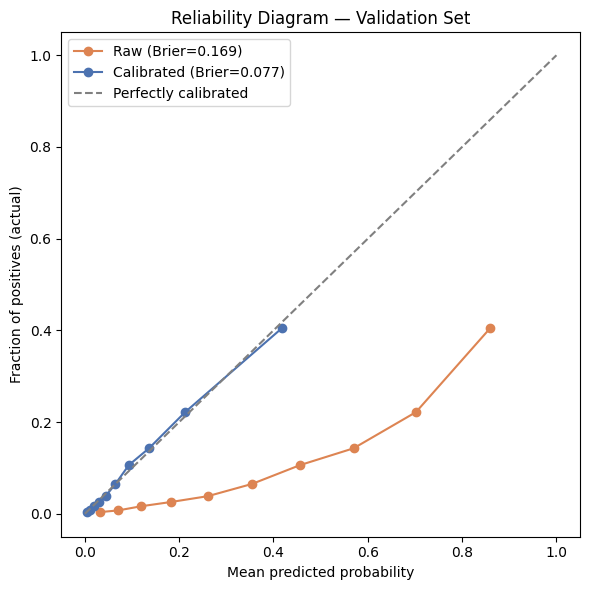

In [46]:
fig, ax = plt.subplots(figsize=(6, 6))

for proba, label, color in [(raw_val_proba, f'Raw (Brier={brier_raw:.3f})', '#dd8452'),
                              (calibrated_val_proba, f'Calibrated (Brier={brier_calibrated:.3f})', '#4c72b0')]:
    frac_pos, mean_pred = calibration_curve(y_val, proba, n_bins=10, strategy='quantile')
    ax.plot(mean_pred, frac_pos, marker='o', label=label, color=color)

ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly calibrated')
ax.set_xlabel('Mean predicted probability')
ax.set_ylabel('Fraction of positives (actual)')
ax.set_title('Reliability Diagram — Validation Set')
ax.legend()
plt.tight_layout()
plt.show()


Default threshold: 0.500 -> would give F1 = 0.2058
Optimized threshold: 0.2052 -> validation F1 = 0.4155


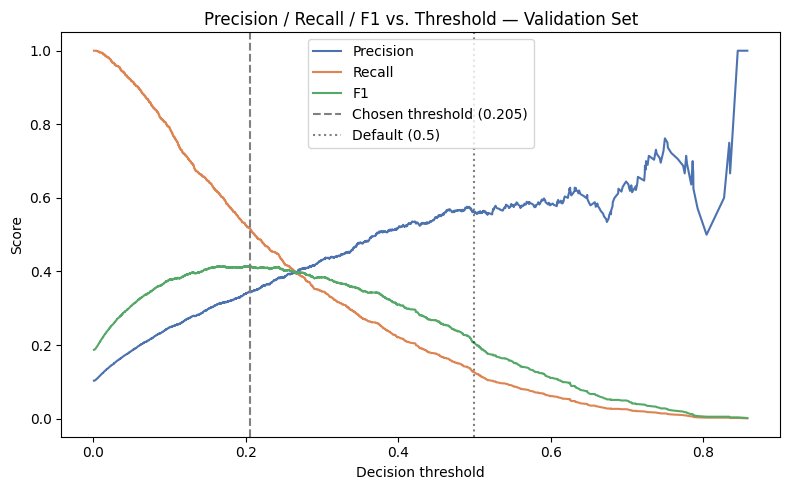

In [47]:
val_proba_for_threshold = calibrated_val_proba if use_calibrated else raw_val_proba

precisions, recalls, thresholds = precision_recall_curve(y_val, val_proba_for_threshold)
f1_scores = np.divide(2 * precisions * recalls, precisions + recalls,
                       out=np.zeros_like(precisions), where=(precisions + recalls) != 0)

best_idx = np.argmax(f1_scores[:-1])  # last point has no corresponding threshold
best_threshold = thresholds[best_idx]

print(f"Default threshold: 0.500 -> would give F1 = {f1_scores[np.argmin(np.abs(thresholds - 0.5))]:.4f}")
print(f"Optimized threshold: {best_threshold:.4f} -> validation F1 = {f1_scores[best_idx]:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions[:-1], label='Precision', color='#4c72b0')
plt.plot(thresholds, recalls[:-1], label='Recall', color='#dd8452')
plt.plot(thresholds, f1_scores[:-1], label='F1', color='#55a868')
plt.axvline(x=best_threshold, linestyle='--', color='gray', label=f'Chosen threshold ({best_threshold:.3f})')
plt.axvline(x=0.5, linestyle=':', color='black', alpha=0.5, label='Default (0.5)')
plt.xlabel('Decision threshold')
plt.ylabel('Score')
plt.title('Precision / Recall / F1 vs. Threshold — Validation Set')
plt.legend()
plt.tight_layout()
plt.show()


In [48]:
test_proba = deployed_model.predict_proba(X_test_scaled)[:, 1]

# Predictions using default and optimized thresholds
test_pred_default = (test_proba >= 0.5).astype(int)
test_pred_optimized = (test_proba >= best_threshold).astype(int)

print("=== Default threshold (0.5) ===")
print(f"Accuracy:  {accuracy_score(y_test, test_pred_default):.4f}")
print(f"Precision: {precision_score(y_test, test_pred_default):.4f}")
print(f"Recall:    {recall_score(y_test, test_pred_default):.4f}")
print(f"F1-score:  {f1_score(y_test, test_pred_default):.4f}")

print(f"\n=== Optimized threshold ({best_threshold:.3f}) ===")
print(f"Accuracy:  {accuracy_score(y_test, test_pred_optimized):.4f}")
print(f"Precision: {precision_score(y_test, test_pred_optimized):.4f}")
print(f"Recall:    {recall_score(y_test, test_pred_optimized):.4f}")
print(f"F1-score:  {f1_score(y_test, test_pred_optimized):.4f}")

# Threshold-independent metrics
test_auc = roc_auc_score(y_test, test_proba)
test_pr_auc = average_precision_score(y_test, test_proba)
test_brier = brier_score_loss(y_test, test_proba)

print(f"\nROC-AUC:     {test_auc:.4f}")
print(f"PR-AUC:      {test_pr_auc:.4f}")
print(f"Brier score: {test_brier:.4f}")

# Use optimized threshold for detailed report
test_pred = test_pred_optimized

=== Default threshold (0.5) ===
Accuracy:  0.8977
Precision: 0.5175
Recall:    0.1248
F1-score:  0.2011

=== Optimized threshold (0.205) ===
Accuracy:  0.8433
Precision: 0.3351
Recall:    0.5270
F1-score:  0.4097

ROC-AUC:     0.8308
PR-AUC:      0.3632
Brier score: 0.0777


In [49]:
print(classification_report(y_test, test_pred, target_names=['No Disease', 'Disease']))


              precision    recall  f1-score   support

  No Disease       0.94      0.88      0.91     10304
     Disease       0.34      0.53      0.41      1186

    accuracy                           0.84     11490
   macro avg       0.64      0.70      0.66     11490
weighted avg       0.88      0.84      0.86     11490



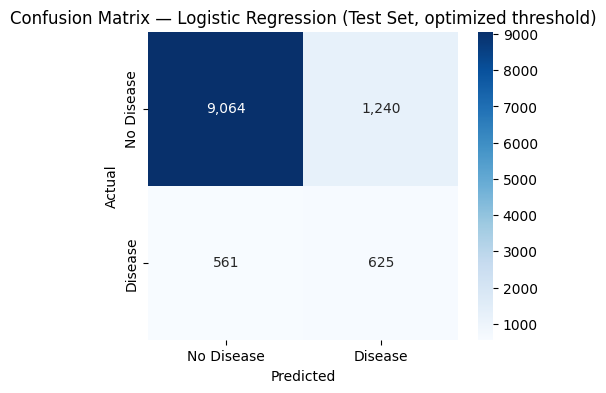

In [50]:
cm = confusion_matrix(y_test, test_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues',
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
plt.title(f'Confusion Matrix — {best_model_name} (Test Set, optimized threshold)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


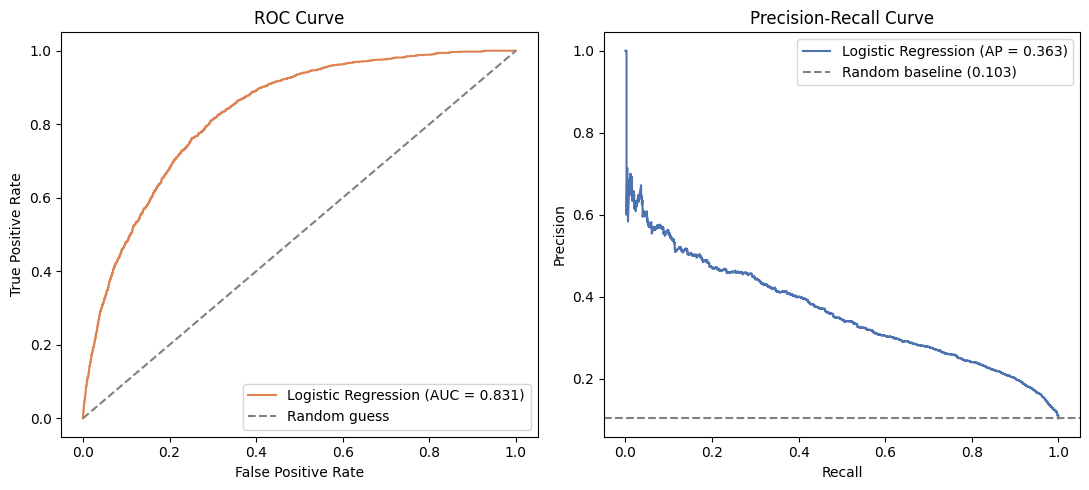

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

fpr, tpr, _ = roc_curve(y_test, test_proba)
axes[0].plot(fpr, tpr, label=f'{best_model_name} (AUC = {test_auc:.3f})', color='#dd8452')
axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend()

precision_curve, recall_curve, _ = precision_recall_curve(y_test, test_proba)
baseline = y_test.mean()
axes[1].plot(recall_curve, precision_curve, label=f'{best_model_name} (AP = {test_pr_auc:.3f})', color='#4c72b0')
axes[1].axhline(y=baseline, linestyle='--', color='gray', label=f'Random baseline ({baseline:.3f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend()

plt.tight_layout()
plt.show()


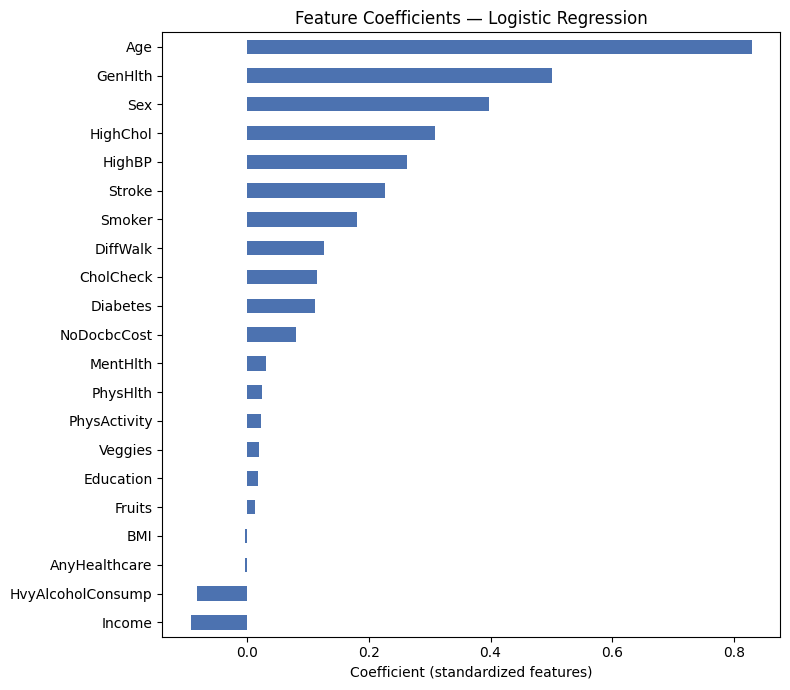

In [52]:
if hasattr(final_model, 'feature_importances_'):
    importances = pd.Series(final_model.feature_importances_, index=X.columns).sort_values()
    plt.figure(figsize=(8, 7))
    importances.plot(kind='barh', color='#4c72b0')
    plt.title(f'Feature Importance — {best_model_name}')
    plt.tight_layout()
    plt.show()
elif hasattr(final_model, 'coef_'):
    importances = pd.Series(final_model.coef_[0], index=X.columns).sort_values()
    plt.figure(figsize=(8, 7))
    importances.plot(kind='barh', color='#4c72b0')
    plt.title(f'Feature Coefficients — {best_model_name}')
    plt.xlabel('Coefficient (standardized features)')
    plt.tight_layout()
    plt.show()
else:
    print("Computing permutation importance on a validation-set subsample (model-agnostic).")

    X_val_sub_df = pd.DataFrame(
        X_val_scaled,
        columns=X.columns
    ).sample(
        min(2000, len(X_val_scaled)),
        random_state=42
    )

    y_val_sub = y_val.loc[X_val_sub_df.index]

    perm = permutation_importance(
        final_model,
        X_val_sub_df,
        y_val_sub,
        n_repeats=5,
        random_state=42,
        scoring='average_precision'
    )

    importances = pd.Series(
        perm.importances_mean,
        index=X.columns
    ).sort_values()

    plt.figure(figsize=(8, 7))
    importances.plot(kind='barh', color='#4c72b0')
    plt.title(f'Permutation Importance (PR-AUC) — {best_model_name}')
    plt.xlabel('Mean decrease in PR-AUC')
    plt.tight_layout()
    plt.show()


In [53]:
def predict_disease_risk(patient: dict, model, scaler, feature_order, threshold=0.5):
    '''
    patient: dict with keys matching feature_order
    Returns: (predicted_label, probability_of_disease)
    '''
    row = pd.DataFrame([patient])[feature_order]
    row_scaled = scaler.transform(row)
    proba = model.predict_proba(row_scaled)[0, 1]
    pred = int(proba >= threshold)
    return pred, proba

example_patient = {
    'HighBP': 1, 'HighChol': 1, 'CholCheck': 1, 'BMI': 31, 'Smoker': 1,
    'Stroke': 0, 'Diabetes': 1, 'PhysActivity': 0, 'Fruits': 0, 'Veggies': 1,
    'HvyAlcoholConsump': 0, 'AnyHealthcare': 1, 'NoDocbcCost': 0, 'GenHlth': 4,
    'MentHlth': 5, 'PhysHlth': 10, 'DiffWalk': 1, 'Sex': 1, 'Age': 10,
    'Education': 4, 'Income': 5
}

pred, proba = predict_disease_risk(example_patient, deployed_model, scaler, X.columns.tolist(), best_threshold)
label = "Higher risk" if pred == 1 else "Lower risk"
print(f"Prediction: {label}")
print(f"Estimated probability of heart disease/attack: {proba*100:.1f}%")
print(f"(Decision threshold used: {best_threshold:.3f}, vs. a naive default of 0.5)")


Prediction: Higher risk
Estimated probability of heart disease/attack: 42.5%
(Decision threshold used: 0.205, vs. a naive default of 0.5)
